# chess-gnn: supervised training

Train the GNN on Lichess PGN data. Runs locally or on Colab (CPU / GPU / MPS).

The supervised objective trains both the policy head and the value head: each PGN position gets the played move as the policy target and the final game result, signed from the side-to-move's perspective, as the value target. This matters for MCTS, because search uses the value head to evaluate newly expanded leaves.

- Local: launch from the repo root so the `chess_gnn` package is importable.
- Colab: the first cell clones/uploads the repo, installs deps, and downloads a small sample PGN.


In [1]:
# --- environment setup ---------------------------------------------------
import sys, os, subprocess, importlib, pathlib

IN_COLAB = "google.colab" in sys.modules
print("colab:", IN_COLAB)

REPO_URL = "https://github.com/jordanshivers/chess-gnn"  # optional: set to your GitHub URL to auto-clone on Colab
REPO_DIR = pathlib.Path("/content/chess") if IN_COLAB else pathlib.Path.cwd().parent

if IN_COLAB:
    if REPO_URL and not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    elif not REPO_DIR.exists():
        # Fallback: upload a zip of the repo via files.upload() and unzip
        from google.colab import files  # type: ignore
        print("No REPO_URL set — upload a zip of the repo (containing src/chess_gnn).")
        up = files.upload()
        name = next(iter(up))
        REPO_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.check_call(["unzip", "-q", name, "-d", str(REPO_DIR)])

    subprocess.check_call([
        "pip", "install", "-q",
        "torch", "torch-geometric", "python-chess", "zstandard", "tqdm",
    ])
    subprocess.check_call(["pip", "install", "-q", "-e", str(REPO_DIR)])

# Make the package importable when running locally from notebooks/
src_path = str((REPO_DIR / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import torch
print("torch:", torch.__version__)
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("device:", DEVICE)

colab: True
torch: 2.10.0+cu128
device: cuda


In [ ]:
# --- data: download a Lichess PGN sample ---------------------------------
# Lichess publishes monthly PGN dumps and an 'Elite' subset. The Elite dumps
# are multi-GB; for a first run, pick a smaller recent monthly or use your own.
# Swap URL as desired: https://database.lichess.org/

DATA_DIR = REPO_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
PGN_URL = "https://database.lichess.org/standard/lichess_db_standard_rated_2019-01.pgn.zst"
PGN_PATH = DATA_DIR / pathlib.Path(PGN_URL).name

if not PGN_PATH.exists():
    subprocess.check_call(["curl", "-L", "--progress-bar", "-o", str(PGN_PATH), PGN_URL])
print("pgn:", PGN_PATH, f"{PGN_PATH.stat().st_size / 1e6:.1f} MB")

pgn: /content/chess/data/lichess_db_standard_rated_2019-01.pgn.zst 10078.5 MB


In [4]:
# --- quick sanity: iterate a few samples ---------------------------------
from chess_gnn.dataset import PGNMoveDataset

ds = PGNMoveDataset([PGN_PATH], shuffle_buffer=256, min_elo=2400)
it = iter(ds)
sample = next(it)
print("node feat:", sample.x.shape, "edges:", sample.edge_index.shape)
print("target move idx:", int(sample.y), "legal moves:", int(sample.legal_mask.sum()))
print("value target:", float(sample.value_target), "(side-to-move POV)")

node feat: torch.Size([64, 45]) edges: torch.Size([2, 4032])
target move idx: 3195 legal moves: 9
value target: 1.0 (side-to-move POV)


In [5]:
# --- train ---------------------------------------------------------------
from chess_gnn.train_sl import train

CKPT_DIR = REPO_DIR / "checkpoints" / "sl"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Tune these for your hardware. On Colab T4, 128 hidden / 4 layers / bs=256 is comfortable.
# `value_coef` trains the value head from game outcomes; keep it on for MCTS-ready checkpoints.
# train(
#     pgn_paths=[PGN_PATH],
#     ckpt_dir=CKPT_DIR,
#     steps=2000,              # bump to 100k+ for real training
#     batch_size=128,
#     lr=3e-4,
#     hidden_dim=128,
#     num_layers=4,
#     num_heads=4,
#     min_elo=1800,
#     num_workers=2,
#     log_every=25,
#     ckpt_every=500,
#     device=DEVICE,
#     value_coef=0.25,
# )
train(
    pgn_paths=[PGN_PATH],
    ckpt_dir=CKPT_DIR,
    steps=10000,              # bump to 100k+ for real training
    batch_size=256,
    lr=3e-4,
    hidden_dim=128,
    num_layers=4,
    num_heads=4,
    min_elo=1800,
    num_workers=12,
    log_every=100,
    ckpt_every=500,
    device=DEVICE,
    value_coef=0.25,
)

step     100 | loss 3.1197 | v 0.9265 | top1 0.210 | top5 0.505 | 1007.0 pos/s
step     200 | loss 2.9562 | v 0.9481 | top1 0.252 | top5 0.552 | 1100.8 pos/s
step     300 | loss 2.9329 | v 0.9394 | top1 0.260 | top5 0.558 | 1091.6 pos/s
step     400 | loss 2.8769 | v 0.9479 | top1 0.275 | top5 0.576 | 1104.9 pos/s
step     500 | loss 2.8513 | v 0.9396 | top1 0.276 | top5 0.584 | 1103.5 pos/s
step     600 | loss 2.8102 | v 0.9300 | top1 0.284 | top5 0.593 | 1108.0 pos/s
step     700 | loss 2.7924 | v 0.9319 | top1 0.283 | top5 0.605 | 1118.8 pos/s
step     800 | loss 2.7871 | v 0.9326 | top1 0.291 | top5 0.605 | 1111.5 pos/s
step     900 | loss 2.7622 | v 0.9402 | top1 0.293 | top5 0.617 | 1121.8 pos/s
step    1000 | loss 2.7004 | v 0.9047 | top1 0.302 | top5 0.630 | 1111.0 pos/s
step    1100 | loss 2.6934 | v 0.8886 | top1 0.303 | top5 0.632 | 1109.1 pos/s
step    1200 | loss 2.6936 | v 0.9152 | top1 0.306 | top5 0.636 | 1113.4 pos/s
step    1300 | loss 2.6696 | v 0.9005 | top1 0.314 |

loading /content/chess/checkpoints/sl/sl_step9500.pt
arch: {'hidden_dim': 128, 'num_layers': 4, 'num_heads': 4, 'dropout': 0.0}
   b8c6  0.650
   g8f6  0.120
   d7d6  0.085
   f8c5  0.030
   d7d5  0.025
   c7c6  0.025
   f7f5  0.010
   f7f6  0.005


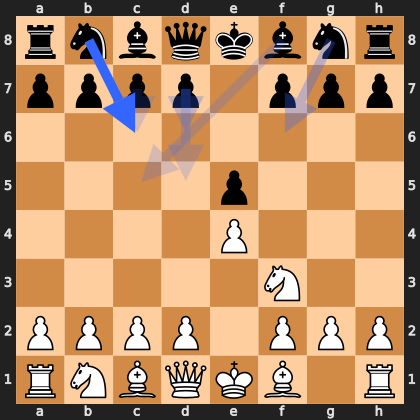

In [6]:
# --- load checkpoint and inspect predictions ------------------------------
import chess
from IPython.display import SVG, display

from chess_gnn.model import load_model
from chess_gnn.play import GNNAgent
from chess_gnn.viz import render_prediction_svg

ckpt = sorted(CKPT_DIR.glob("sl_*.pt"))[-1]
print("loading", ckpt)
model = load_model(ckpt, device=DEVICE)  # reads arch config from the checkpoint
# model = load_model(ckpt, device=DEVICE, hidden_dim=64, num_layers=3, num_heads=2)
print("arch:", model.config)
# num_simulations=200 enables PUCT MCTS; set to 0 for raw policy (much faster).
# MCTS is useful only for checkpoints trained with value supervision, as above.
agent = GNNAgent(model, device=DEVICE, default_temperature=0.3, num_simulations=200)

board = chess.Board()
board.push_san("e4"); board.push_san("e5"); board.push_san("Nf3")
ranking = agent.rank_moves(board)
for m, p in list(zip(ranking.moves, ranking.probabilities))[:8]:
    print(f"  {m.uci():>5s}  {p:.3f}")
display(SVG(render_prediction_svg(board, ranking, topk=6)))

result: * plies: 8


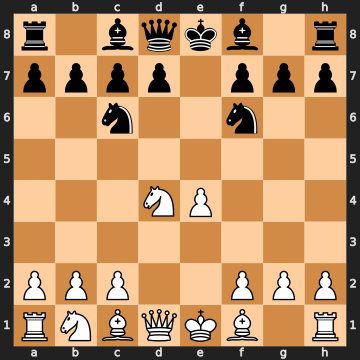

In [7]:
# --- optional: play a short self-play game at low temperature ------------
from chess_gnn.play import play_game

final_board, result = play_game(agent, agent, temperature=0.2, max_plies=8)
print("result:", result, "plies:", final_board.ply())
display(SVG(chess.svg.board(final_board, size=360)))

In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")
# !cp -r /content/chess/checkpoints /content/drive/MyDrive/chess-gnn-checkpoints



Mounted at /content/drive
